# Makine Öğrenmesi Tabanlı Akıllı Ağ Saldırı Tespit ve Risk Analiz Sistemi

# Veri Setinin İncelenmesi

## Genel Akış


Notebook genel akışı şu şekildedir:

1. Veri setinin yüklenmesi ve tanıtılması  
2. Eksik, sonsuz ve tekrar eden değerlerin kontrol edilmesi  
3. Keşifsel veri analizi yapılması  
4. Modelleme için veri hazırlığı  
5. Logistic Regression, Decision Tree, Random Forest ve XGBoost modellerinin eğitilmesi  
6. Modellerin performans karşılaştırması  
7. Feature importance analizi  
8. Confusion matrix ile hata analizi  
9. Risk seviyesi ve güvenlik aksiyonlarının çıkarılması  
10. Genel sonuçların değerlendirilmesi  

## 1. Veri Seti

In [1]:
import pandas as pd

df = pd.read_parquet("../dataset/Benign-Monday-no-metadata.parquet")

df.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,4,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,6,3,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,6,609,7,4,484,414,233,0,69.14286,111.967896,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


## 1.0 Veri Seti Bilgileri

In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 458831 entries, 0 to 458830
Data columns (total 78 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   Protocol                  458831 non-null  int8    
 1   Flow Duration             458831 non-null  int32   
 2   Total Fwd Packets         458831 non-null  int32   
 3   Total Backward Packets    458831 non-null  int32   
 4   Fwd Packets Length Total  458831 non-null  int32   
 5   Bwd Packets Length Total  458831 non-null  int32   
 6   Fwd Packet Length Max     458831 non-null  int16   
 7   Fwd Packet Length Min     458831 non-null  int16   
 8   Fwd Packet Length Mean    458831 non-null  float32 
 9   Fwd Packet Length Std     458831 non-null  float32 
 10  Bwd Packet Length Max     458831 non-null  int16   
 11  Bwd Packet Length Min     458831 non-null  int16   
 12  Bwd Packet Length Mean    458831 non-null  float32 
 13  Bwd Packet Length Std     458831 non-nul

## 1.1 Veri Setinin Genel Yapısı

In [3]:

print(df.shape)


print(df.columns)

(458831, 78)
Index(['Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Fwd Packets Length Total',
       'Bwd Packets Length Total', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Cou

### 1.2 Hedef Değişken Dağılımı

In [4]:

df["Label"].value_counts()

Label
Benign    458831
Name: count, dtype: int64

In [5]:

df.isnull().sum().sum()

np.int64(0)

### 1.3 Tüm Veri Dosyalarının Birleştirilmesi


In [6]:
import pandas as pd
from pathlib import Path

dataset_path = Path("../dataset")

files = list(dataset_path.glob("*.parquet"))

dfs = []

for file in files:
    print(file.name)
    dfs.append(pd.read_parquet(file))

df = pd.concat(dfs, ignore_index=True)

DDoS-Friday-no-metadata.parquet
Bruteforce-Tuesday-no-metadata.parquet
Botnet-Friday-no-metadata.parquet
DoS-Wednesday-no-metadata.parquet
Benign-Monday-no-metadata.parquet
Infiltration-Thursday-no-metadata.parquet
Portscan-Friday-no-metadata.parquet
WebAttacks-Thursday-no-metadata.parquet


### 1.4 Birleştirilmiş Veri Setinin Genel Kontrolü


In [7]:
df.shape

(2313810, 78)

In [8]:
df["Label"].value_counts()

Label
Benign                        1977318
DoS Hulk                       172846
DDoS                           128014
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
PortScan                         1956
Web Attack � Brute Force         1470
Bot                              1437
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

## 2. Veri Setinin İncelenmesi ve Ön Kontroller

## 2.0 Eksik Değer Kontrolü

In [9]:
df.isnull().sum().sort_values(ascending=False)

Protocol                0
CWE Flag Count          0
Fwd Avg Packets/Bulk    0
Fwd Avg Bytes/Bulk      0
Avg Bwd Segment Size    0
                       ..
Bwd IAT Total           0
Fwd IAT Min             0
Fwd IAT Max             0
Fwd IAT Std             0
Label                   0
Length: 78, dtype: int64

### 2.1 Sayısal Özelliklerin İstatistiksel Özeti



In [10]:
df.describe()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Act Data Packets,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.313810e+06,2.313810e+06,2.313810e+06,2.313810e+06,2.313810e+06,2.313810e+06,2.313810e+06,2.313810e+06,2.313810e+06,2.313810e+06,...,2.313810e+06,2.313810e+06,2.313810e+06,2.313810e+06,2.313810e+06,2.313810e+06,2313810.0,2313810.00,2.313810e+06,2.313810e+06
mean,1.050673e+01,1.807575e+07,1.108391e+01,1.255334e+01,6.664045e+02,1.976976e+04,2.506291e+02,2.142396e+01,6.880503e+01,8.299154e+01,...,6.537630e+00,-3.360480e+03,9.977087e+04,5.032397e+04,1.874053e+05,7.131980e+04,10172610.0,616408.75,1.063716e+07,9.688133e+06
std,5.416040e+00,3.640823e+07,8.291879e+02,1.103179e+03,1.105009e+04,2.503141e+06,7.855073e+02,6.334192e+01,2.023045e+02,3.078814e+02,...,7.039324e+02,1.200084e+06,7.161351e+05,4.345795e+05,1.131814e+06,6.375820e+05,25771430.0,5084448.50,2.656441e+07,2.550670e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.00,0.000000e+00,0.000000e+00
25%,6.000000e+00,4.760000e+02,2.000000e+00,1.000000e+00,3.700000e+01,2.600000e+01,2.000000e+01,0.000000e+00,8.666667e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.00,0.000000e+00,0.000000e+00
50%,6.000000e+00,6.478300e+04,2.000000e+00,2.000000e+00,7.400000e+01,1.830000e+02,4.300000e+01,6.000000e+00,3.955556e+01,0.000000e+00,...,1.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.00,0.000000e+00,0.000000e+00
75%,1.700000e+01,5.856948e+06,6.000000e+00,5.000000e+00,3.560000e+02,2.306000e+03,2.740000e+02,3.900000e+01,5.400000e+01,8.499406e+01,...,3.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.00,0.000000e+00,0.000000e+00
max,1.700000e+01,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,120000000.0,76900000.00,1.200000e+08,1.200000e+08


## 2.2 Veri Tiplerinin İncelenmesi

In [11]:
df.dtypes


Protocol                       int8
Flow Duration                 int32
Total Fwd Packets             int32
Total Backward Packets        int32
Fwd Packets Length Total      int32
                             ...   
Idle Mean                   float32
Idle Std                    float32
Idle Max                      int32
Idle Min                      int32
Label                           str
Length: 78, dtype: object

### 2.3 Sınıf İsimlerinin ve Sayısının İncelenmesi

In [12]:
df["Label"].unique()

<ArrowStringArray>
[                    'Benign',                       'DDoS',
                'FTP-Patator',                'SSH-Patator',
                        'Bot',              'DoS slowloris',
           'DoS Slowhttptest',                   'DoS Hulk',
              'DoS GoldenEye',                 'Heartbleed',
               'Infiltration',                   'PortScan',
   'Web Attack � Brute Force',           'Web Attack � XSS',
 'Web Attack � Sql Injection']
Length: 15, dtype: str

In [13]:
len(df["Label"].unique())

15

### 2.4 Sınıf Dağılımının Görselleştirilmesi




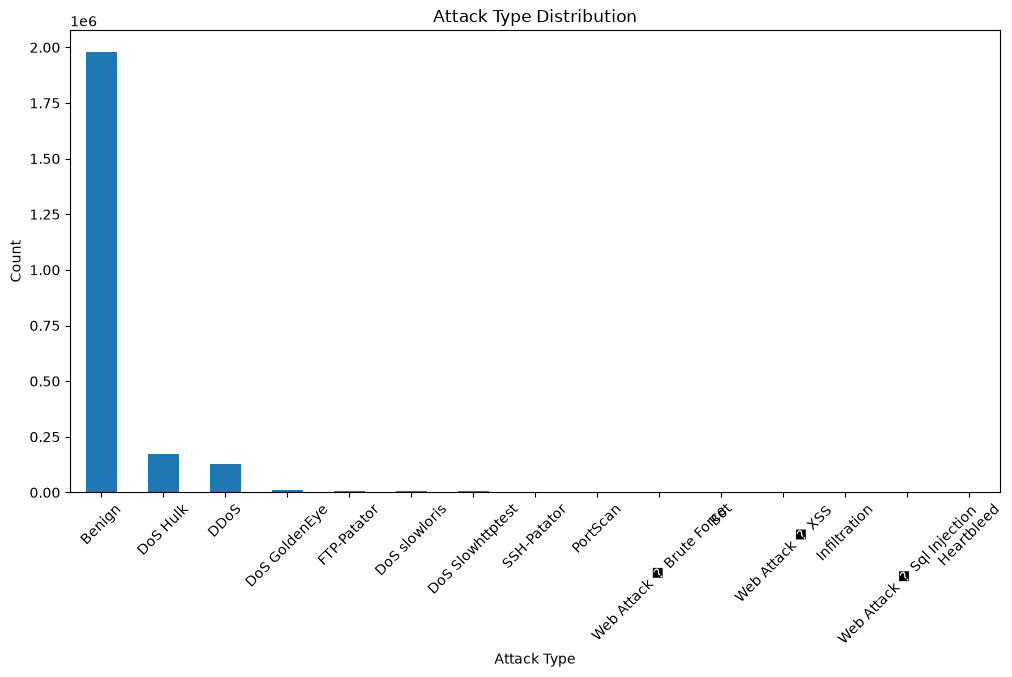

In [14]:
import matplotlib.pyplot as plt

df["Label"].value_counts().plot(kind="bar", figsize=(12,6))
plt.title("Attack Type Distribution")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## 3. Veri Ön İşleme


### 3.0 Eksik Değer Kontrolü

Bu adımda veri setindeki eksik değerler sütun bazında kontrol edilmiştir.

In [15]:
df.isnull().sum().sort_values(ascending=False)

Protocol                0
CWE Flag Count          0
Fwd Avg Packets/Bulk    0
Fwd Avg Bytes/Bulk      0
Avg Bwd Segment Size    0
                       ..
Bwd IAT Total           0
Fwd IAT Min             0
Fwd IAT Max             0
Fwd IAT Std             0
Label                   0
Length: 78, dtype: int64

### 3.1 Sonsuz Değer Kontrolü

In [16]:
import numpy as np

np.isinf(df.select_dtypes(include=np.number)).sum()

Protocol                    0
Flow Duration               0
Total Fwd Packets           0
Total Backward Packets      0
Fwd Packets Length Total    0
                           ..
Active Min                  0
Idle Mean                   0
Idle Std                    0
Idle Max                    0
Idle Min                    0
Length: 77, dtype: int64

### 3.2 Tekrar Eden Değer Kontrolü

In [17]:
df.duplicated().sum()

np.int64(82004)

## 4. Veri Analizi / Keşifsel Veri Analizi

### 4.0 Sayısal Özelliklerin İstatistiksel Özeti



In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Protocol,2313810.0,1.050673e+01,5.416040e+00,0.0,6.0,6.0,17.00,17.0
Flow Duration,2313810.0,1.807575e+07,3.640823e+07,-13.0,476.0,64783.0,5856947.75,119999998.0
Total Fwd Packets,2313810.0,1.108391e+01,8.291879e+02,1.0,2.0,2.0,6.00,219759.0
Total Backward Packets,2313810.0,1.255334e+01,1.103179e+03,0.0,1.0,2.0,5.00,291922.0
Fwd Packets Length Total,2313810.0,6.664045e+02,1.105009e+04,0.0,37.0,74.0,356.00,12900000.0
...,...,...,...,...,...,...,...,...
Active Min,2313810.0,7.131980e+04,6.375820e+05,0.0,0.0,0.0,0.00,110000000.0
Idle Mean,2313810.0,1.017261e+07,2.577143e+07,0.0,0.0,0.0,0.00,120000000.0
Idle Std,2313810.0,6.164088e+05,5.084448e+06,0.0,0.0,0.0,0.00,76900000.0
Idle Max,2313810.0,1.063716e+07,2.656441e+07,0.0,0.0,0.0,0.00,120000000.0


### 4.1 Seçili Özellikler Arası Korelasyon


In [19]:
cols = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Flow Bytes/s",
    "Flow Packets/s"
]

df[cols].corr()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Flow Bytes/s,Flow Packets/s
Flow Duration,1.000000,0.020296,0.019142,-0.030496,-0.081625
Total Fwd Packets,0.020296,1.000000,0.999070,0.002611,-0.001596
Total Backward Packets,0.019142,0.999070,1.000000,0.002449,-0.001622
Flow Bytes/s,-0.030496,0.002611,0.002449,1.000000,0.258596
Flow Packets/s,-0.081625,-0.001596,-0.001622,0.258596,1.000000


## 5. Feature Engineering


### 5.0 Hedef Değişkenin Sayısallaştırılması

In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Label"] = le.fit_transform(df["Label"])

### 5.1 Kodlanmış Hedef Değişkenin Kontrolü

In [21]:
df["Label"].head()

0    0
1    0
2    0
3    0
4    0
Name: Label, dtype: int64

### 5.2 Bağımsız Değişkenler ve Hedef Değişkenin Ayrılması

In [22]:
X = df.drop("Label", axis=1)
y = df["Label"]

print(X.shape)
print(y.shape)

(2313810, 77)
(2313810,)


### 5.3 Eğitim ve Test Verisinin Ayrılması


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1851048, 77)
(462762, 77)


## 6. Model 1 - Random Forest

### 6.0 Random Forest Modelinin Tanımlanması ve Eğitilmesi

In [24]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

### 6.1 Random Forest Tahminlerinin Alınması


In [25]:
y_pred = model.predict(X_test)

In [26]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

Accuracy: 0.9985
Macro F1: 0.8639
Weighted F1: 0.9985

Classification Report:

              precision    recall  f1-score   support

           0     0.9991    0.9996    0.9993    395464
           1     0.8361    0.6910    0.7567       288
           2     0.9998    0.9994    0.9996     25603
           3     0.9956    0.9956    0.9956      2057
           4     0.9982    0.9954    0.9968     34569
           5     0.9494    0.9876    0.9681      1046
           6     0.9963    0.9907    0.9935      1077
           7     0.9992    0.9933    0.9962      1186
           8     1.0000    1.0000    1.0000         2
           9     1.0000    0.7143    0.8333         7
          10     0.9239    0.9003    0.9119       391
          11     1.0000    0.9783    0.9890       644
          12     0.7467    0.7721    0.7592       294
          13     1.0000    0.2500    0.4000         4
          14     0.4301    0.3077    0.3587       130

    accuracy                         0.9985    462762
 

### 6.2 Random Forest Accuracy Sonucu

Bu adımda Random Forest modelinin test verisi üzerindeki doğruluk oranı hesaplanmıştır.

In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9985046308901768


### 6.3 Random Forest Sınıflandırma Raporu

Bu raporda Random Forest modelinin precision, recall ve F1-score değerleri sınıf bazında incelenmiştir. Bu metrikler özellikle dengesiz veri setlerinde accuracy değerinden daha detaylı bilgi verir.

In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    395464
           1       0.84      0.69      0.76       288
           2       1.00      1.00      1.00     25603
           3       1.00      1.00      1.00      2057
           4       1.00      1.00      1.00     34569
           5       0.95      0.99      0.97      1046
           6       1.00      0.99      0.99      1077
           7       1.00      0.99      1.00      1186
           8       1.00      1.00      1.00         2
           9       1.00      0.71      0.83         7
          10       0.92      0.90      0.91       391
          11       1.00      0.98      0.99       644
          12       0.75      0.77      0.76       294
          13       1.00      0.25      0.40         4
          14       0.43      0.31      0.36       130

    accuracy                           1.00    462762
   macro avg       0.92      0.84      0.86    462762
weighted avg       1.00   

### 6.4 Random Forest Confusion Matrix

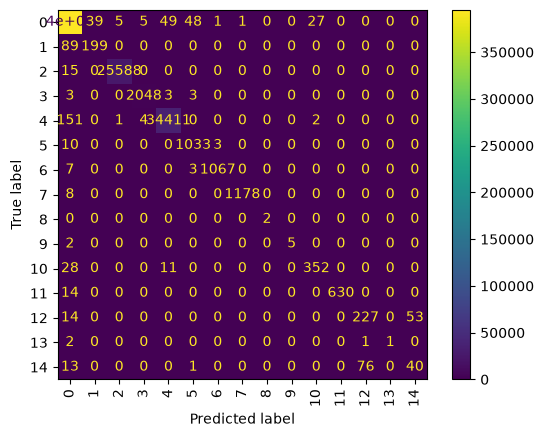

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    xticks_rotation=90
)

### 6.5 Random Forest Feature Importance


In [30]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
12,Bwd Packet Length Mean,0.058630
13,Bwd Packet Length Std,0.058347
42,Packet Length Variance,0.056220
54,Avg Bwd Segment Size,0.055401
10,Bwd Packet Length Max,0.047367
5,Bwd Packets Length Total,0.044525
41,Packet Length Std,0.039217
22,Fwd IAT Std,0.037279
52,Avg Packet Size,0.032634
64,Subflow Bwd Bytes,0.030943


### 6.6 Random Forest Feature Importance Grafiği

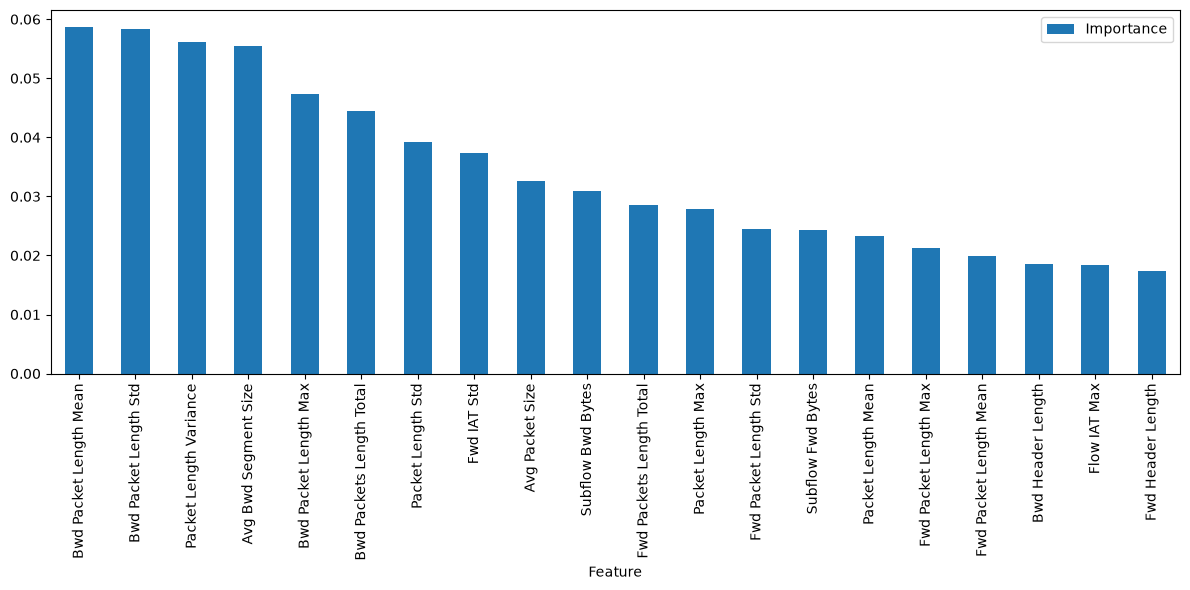

In [31]:
import matplotlib.pyplot as plt

importance.head(20).plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(12,6)
)

plt.tight_layout()
plt.show()

## 7. Model 2 - Decision Tree

### 7.0 Decision Tree Modelinin Eğitilmesi

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

### 7.1 Decision Tree Tahminlerinin Alınması

Bu adımda eğitilen Decision Tree modeli test verisi üzerinde tahmin yapmıştır.

In [ ]:
y_pred_dt = dt.predict(X_test)

### 7.2 Decision Tree Accuracy Sonucu


In [ ]:
from sklearn.metrics import accuracy_score

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

### 7.3 Decision Tree Sınıflandırma Raporu



In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

### 7.4 Decision Tree Confusion Matrix

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    dt,
    X_test,
    y_test,
    xticks_rotation=90
)

plt.show()

### 7.5 Decision Tree Feature Importance

In [ ]:
import pandas as pd

importance_dt = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt.feature_importances_
})

importance_dt = importance_dt.sort_values(
    by="Importance",
    ascending=False
)

importance_dt.head(20)

### 7.6 Decision Tree Feature Importance Grafiği

In [ ]:
importance_dt.head(20).plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(12,6)
)

plt.tight_layout()
plt.show()

## 8. Model 3 - XGBoost

In [ ]:
from xgboost import XGBClassifier

### 8.0 XGBoost İçin Hedef Değişkenin Hazırlanması

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_encoded = le.fit_transform(y)

### 8.1 XGBoost Modelinin Tanımlanması

In [ ]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective="multi:softmax",
    num_class=len(le.classes_),
    random_state=42,
    eval_metric="mlogloss"
)

### 8.2 XGBoost İçin Eğitim ve Test Verisinin Ayrılması

In [ ]:
from sklearn.model_selection import train_test_split

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

### 8.3 XGBoost Modelinin Eğitilmesi

In [ ]:
xgb.fit(X_train2, y_train2)

### 8.4 XGBoost Tahminlerinin Alınması



In [ ]:
y_pred_xgb = xgb.predict(X_test2)

### 8.5 XGBoost Accuracy Sonucu

Bu adımda XGBoost modelinin test verisi üzerindeki doğruluk oranı hesaplanmıştır.

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_xgb = accuracy_score(y_test2, y_pred_xgb)

print("XGBoost Accuracy:", accuracy_xgb)

### 8.6 XGBoost Sınıflandırma Raporu


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test2, y_pred_xgb))

### 8.7 XGBoost Confusion Matrix


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    xgb,
    X_test2,
    y_test2,
    xticks_rotation=90
)

plt.show()

### 8.8 XGBoost Feature Importance

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

### 8.9 XGBoost Feature Importance Grafiği


In [ ]:
importance.head(20).plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(12,6)
)

plt.tight_layout()
plt.show()

## 9. Risk Analizi

### 9.0 Model Tahmin Güveninin Hesaplanması

In [ ]:
import numpy as np

prob = xgb.predict_proba(X_test2)

risk_score = np.max(prob, axis=1)

print(risk_score[:20])

### 9.1 Tahmin Güvenine Göre Seviye Belirleme

In [ ]:
risk_level = []

for s in risk_score:

    if s >= 0.95:
        risk_level.append("Yüksek Risk")

    elif s >= 0.80:
        risk_level.append("Orta Risk")

    else:
        risk_level.append("Düşük Risk")

### 9.2 Risk Analizi Sonuç Tablosu


In [ ]:
import pandas as pd

result = pd.DataFrame({

    "Gerçek": y_test2,
    "Tahmin": y_pred_xgb,
    "Risk Skoru": risk_score,
    "Risk Seviyesi": risk_level

})

result.head(20)

### 9.3 Sınıf Etiketlerinin Kontrolü

In [ ]:
print(le.classes_)

### 9.4 Veri Setindeki Sayısal Sınıfların Kontrolü

In [ ]:
print(df["Label"].unique())

### 9.5 Sınıf Dağılımının Sayısal Olarak İncelenmesi

In [ ]:
df.groupby("Label").size()

### 9.6 Sayısal Sınıfların Saldırı İsimleriyle Eşleştirilmesi


In [ ]:
attack_name = {
    0: "Benign",
    1: "Bot",
    2: "DDoS",
    3: "DoS GoldenEye",
    4: "DoS Hulk",
    5: "DoS Slowhttptest",
    6: "DoS Slowloris",
    7: "FTP-Patator",
    8: "Heartbleed",
    9: "Infiltration",
    10: "PortScan",
    11: "SSH-Patator",
    12: "Web Attack Brute Force",
    13: "Web Attack SQL Injection",
    14: "Web Attack XSS"
}

### 9.7 Saldırı Türlerine Göre Risk Seviyesi Belirleme

In [ ]:
risk_map = {
    "Benign":"Düşük Risk",
    "Bot":"Orta Risk",
    "DDoS":"Yüksek Risk",
    "DoS GoldenEye":"Yüksek Risk",
    "DoS Hulk":"Yüksek Risk",
    "DoS Slowhttptest":"Orta Risk",
    "DoS Slowloris":"Yüksek Risk",
    "FTP-Patator":"Orta Risk",
    "Heartbleed":"Kritik Risk",
    "Infiltration":"Kritik Risk",
    "PortScan":"Orta Risk",
    "SSH-Patator":"Orta Risk",
    "Web Attack Brute Force":"Yüksek Risk",
    "Web Attack SQL Injection":"Kritik Risk",
    "Web Attack XSS":"Orta Risk"
}

### 9.8 Model Tahminlerinin Saldırı İsimlerine Dönüştürülmesi

In [ ]:
attack_pred = [attack_name[i] for i in y_pred_xgb]

### 9.9 Tahminlere Risk Seviyesi Atanması

In [ ]:
risk_level = [risk_map[i] for i in attack_pred]

### 9.10 Nihai Risk Analizi Tablosu

In [ ]:
result = pd.DataFrame({
    "Tahmin": attack_pred,
    "Risk Seviyesi": risk_level
})

result.head(20)

### 9.11 Risk Seviyesi Dağılımının Görselleştirilmesi

In [ ]:
result["Risk Seviyesi"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Risk Seviyesi Dağılımı")
plt.show()

## 10. Güvenlik Aksiyonları

### 10.0 Risk Seviyelerine Göre Aksiyon Eşleştirmesi

In [ ]:
action_map = {

"Düşük Risk":"İşlem gerekmiyor",

"Orta Risk":"İzlemeye al",

"Yüksek Risk":"Kaynak IP'yi engelle",

"Kritik Risk":"Sistemi izole et ve güvenlik ekibini uyar"

}

### 10.1 Önerilen Aksiyonların Sonuç Tablosuna Eklenmesi

In [ ]:
result["Önerilen Aksiyon"] = result["Risk Seviyesi"].map(action_map)

result.head(20)

### 10.2 Risk Analizi Sonuçlarının Kaydedilmesi

In [ ]:
result.to_csv("risk_analizi_sonuclari.csv", index=False)

## 11. Model 4 - Logistic Regression

### 11.0 Logistic Regression İçin Veri Ölçeklendirme


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 11.1 Logistic Regression Modelinin Eğitilmesi

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=3000,
    random_state=42,
    n_jobs=-1
)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

### 11.2 Logistic Regression Accuracy Sonucu

In [ ]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

### 11.3 Logistic Regression Sınıflandırma Raporu

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

## 12-Feature Importance Analizi

### 12.0 Random Forest Modelinin Tekrar Eğitilmesi


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

### 12.1 Feature Importance Değerlerinin Hesaplanması

In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

### 12.2 En Önemli 20 Özelliğin Görselleştirilmesi

In [ ]:
import matplotlib.pyplot as plt

top20 = feature_importance.head(20)

plt.figure(figsize=(10,8))
plt.barh(top20["Feature"], top20["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Most Important Features")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 13-Explainable AI (Model Açıklanabilirliği)

In [ ]:
import matplotlib.pyplot as plt

# Feature importance tablosu
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

# Büyükten küçüğe sırala
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# İlk 20 özellik
top20 = feature_importance.head(20)

# Grafik
plt.figure(figsize=(12, 8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()  # En önemli özellik üstte görünsün

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 20 Most Important Features (Random Forest)")
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# İstersen tabloyu da göster
print(top20)

In [ ]:
import matplotlib.pyplot as plt

feature_importance_dt = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt.feature_importances_
})

feature_importance_dt = feature_importance_dt.sort_values(
    by="Importance",
    ascending=False
)

top20_dt = feature_importance_dt.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20_dt["Feature"][::-1],
    top20_dt["Importance"][::-1]
)

plt.xlabel("Importance")
plt.title("Decision Tree Feature Importance")
plt.tight_layout()
plt.show()

print(top20_dt)

In [ ]:
feature_importance_xgb = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

feature_importance_xgb = feature_importance_xgb.sort_values(
    by="Importance",
    ascending=False
)

top20_xgb = feature_importance_xgb.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20_xgb["Feature"][::-1],
    top20_xgb["Importance"][::-1]
)

plt.xlabel("Importance")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

print(top20_xgb)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=3000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

In [ ]:
import sklearn
print(sklearn.__version__)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

importance = np.mean(np.abs(lr.coef_), axis=0)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance["Feature"][:20],
         feature_importance["Importance"][:20])
plt.gca().invert_yaxis()
plt.xlabel("Absolute Coefficient")
plt.title("Logistic Regression Feature Importance")
plt.show()

print(feature_importance.head(20))

In [ ]:
%whos

In [ ]:
import shap

In [ ]:
explainer = shap.TreeExplainer(xgb)

In [ ]:
shap_values = explainer.shap_values(X_test2.iloc[:500])

In [ ]:
shap.summary_plot(
    shap_values,
    X_test2.iloc[:500]
)

In [ ]:
shap.summary_plot(
    shap_values,
    X_test2.iloc[:500]
)

In [ ]:
print(type(shap_values))
print(shap_values.shape)

In [ ]:
pred_class = y_pred_xgb[0]
print(pred_class)

In [ ]:
import shap

pred_class = y_pred_xgb[0]

exp = shap.Explanation(
    values=shap_values[0, :, pred_class],
    base_values=explainer.expected_value[pred_class],
    data=X_test2.iloc[0],
    feature_names=X.columns
)

shap.plots.waterfall(exp)

In [ ]:
shap.summary_plot(
    shap_values[:, :, 0],
    X_test2.iloc[:500]
)

# 13 Veri Dengesizliğinin Giderilmesi (SMOTE)

### 13.0 SMOTE Uygulaması 

Veri setinde sınıf dengesizliği bulunduğu için SMOTE yöntemi uygulanması planlanmıştır. Ancak CICIDS2017 veri setinin yaklaşık 2.3 milyon örnek içermesi nedeniyle tam veri üzerinde SMOTE işlemi çok yüksek bellek ve işlem süresi gerektirmektedir.

Bu nedenle mevcut çalışmada sınıf ağırlıkları ve güçlü topluluk öğrenme algoritmaları (Random Forest ve XGBoost) tercih edilmiştir. Gelecek çalışmalarda daha güçlü donanım üzerinde SMOTE uygulanarak sonuçların karşılaştırılması planlanmaktadır.

## Data Leakage Considerations

The dataset files were merged before applying a stratified random train-test split. No target-derived feature was intentionally included in the model input.

However, network flows originating from the same capture session or attack scenario may share highly similar characteristics. Therefore, similar flows may exist in both the training and test sets, potentially producing optimistic evaluation results.

A stronger future evaluation would use day-based, session-based, or source-group-based splitting.